In [6]:
import torch
x = torch.arange(4.0)
x

tensor([0., 1., 2., 3.])

In [7]:
x.requires_grad_(True)
x.grad

In [10]:
y = 2*torch.dot(x,x)
y

tensor(28., grad_fn=<MulBackward0>)

In [11]:
y.backward()
x.grad

tensor([ 0.,  4.,  8., 12.])

In [14]:
x.grad.zero_()
y = x*x
u = y.detach()
z = u*x
z.sum().backward()
x.grad == u


tensor([True, True, True, True])

In [15]:
x.grad.zero_()
y.sum().backward()
x.grad == 2*x

tensor([True, True, True, True])

In [17]:
def f(a):
    b = 2*a
    while b.norm() < 1000:
        b = 2*b
    if b.sum() > 0:
        c = b
    else:
        c = 100*b
    return c
a = torch.randn(size=(),requires_grad=True)
d = f(a)
d.backward()

a.grad == d/a

tensor(True)

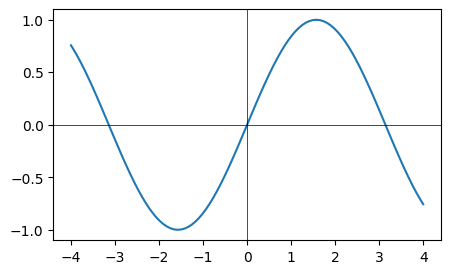

In [23]:
import matplotlib.pyplot as plt
import numpy as np
def f(x):
    return np.sin(x)
x = np.linspace(-4,4,100)
y = f(x)
plt.figure(figsize=(5,3))
plt.plot(x, y)
plt.axhline(0, color='black', linewidth=0.5) 
plt.axvline(0, color='black', linewidth=0.5)
plt.show()

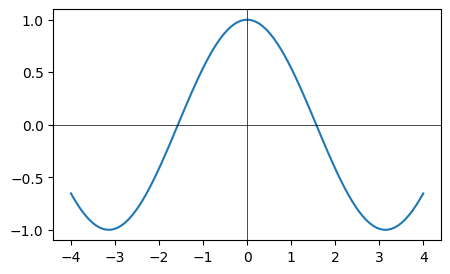

In [29]:
x = torch.linspace(-4, 4, 100, requires_grad=True)
y = torch.sin(x)
y.sum().backward()
a = x.grad
x_np = x.detach().numpy()
y_np = a.detach().numpy()
plt.figure(figsize=(5,3))
plt.plot(x_np,y_np)
plt.axhline(0, color='black', linewidth=0.5) 
plt.axvline(0, color='black', linewidth=0.5)
plt.show()